<a href="https://colab.research.google.com/github/kurkur19/NLP_al_khmuz/blob/main/Al_Khmuz_NLP_4lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Аль Хмуз Карина Бассамівна БС-25
Практична робота №4

**РЕАЛІЗАЦІЯ МОДЕЛІ WORD2VEC ЗА ДОПОМОГОЮ БІБЛІОТЕКИ GENSIM**

Встановлюємо бібліотеку gensim для обробки тексту та роботи з векторними уявленнями слів.

In [1]:
!pip install gensim




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.0 MB/s eta 0:00:00


Встановлюємо numpy версії 1.23.5 для роботи з багатовимірними масивами та числовими обчисленнями.

In [2]:
!pip install numpy==1.23.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 70.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


Імпортуємо бібліотеки та завантажувач моделей gensim

In [3]:
import gensim.downloader as api
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

Завантажуємо переднавчену модель word2vec-google-news-300 із gensim

In [4]:
print("Завантажуємо переднавчену модель...")
model = api.load("word2vec-google-news-300")
print("Модель успішно завантажена!")

Завантажуємо переднавчену модель...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Модель успішно завантажена!


In [5]:
print("Схожі слова до 'cheese':")
similar_words = model.most_similar("cheese", topn=10)
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Схожі слова до 'cheese':
cheeses: 0.7789
cheddar: 0.7628
goat_cheese: 0.7297
Cheese: 0.7287
cheddar_cheese: 0.7255
Cheddar_cheese: 0.6944
mozzarella: 0.6806
cheddar_cheeses: 0.6695
Camembert: 0.6623
gruyere: 0.6615


Ми знайшли 10 найбільш схожих слів до "cheese" за допомогою моделі word2vec і вивели їх разом із коефіцієнтами схожості.

In [6]:
print("\nПропорція: 'king' : 'man' :: 'queen' : ?")
analogy_result = model.most_similar(positive=["queen", "man"],
                                    negative=["king"])
print("\nРезультат аналогії ('king' : 'man' :: 'queen' : ?):")
for word, similarity in analogy_result[:5]:
    print(f"{word}: {similarity:.4f}")


Пропорція: 'king' : 'man' :: 'queen' : ?

Результат аналогії ('king' : 'man' :: 'queen' : ?):
woman: 0.7609
girl: 0.6140
teenage_girl: 0.6041
teenager: 0.5826
lady: 0.5753


Зробили аналогію "king" : "man" :: "queen" : ?" за допомогою word2vec, та знайли найближчі слова і вивели топ-5 результатів із їхніми коефіцієнтами схожості.

Давайте візьмемо векторні представлення вибраних слів із моделі word2vec, знизимо їхню розмірність до 2D за допомогою t-SNE та побудуємо графік для візуалізації зв'язків між словами.

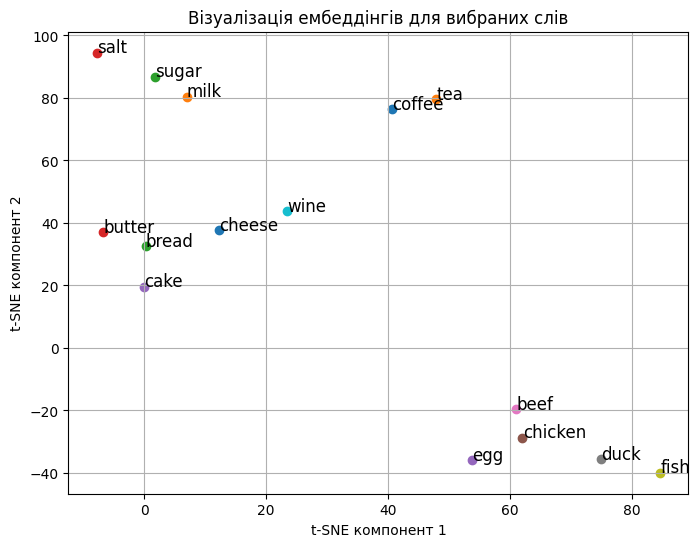

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

words = ["cheese", "milk", "bread", "butter", "cake", "chicken", "beef", "duck", "fish", "wine", "coffee", "tea", "sugar", "salt", "egg"]
word_vectors = np.array([model[word] for word in words])

tsne = TSNE(n_components=2, perplexity=2, random_state=42)
reduced_vectors = tsne.fit_transform(word_vectors)

plt.figure(figsize=(8, 6))

for i, word in enumerate(words):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1])
    plt.text(reduced_vectors[i, 0] + 0.05, reduced_vectors[i, 1] + 0.05, word, fontsize=12)

plt.title("Візуалізація ембеддінгів для вибраних слів")
plt.xlabel("t-SNE компонент 1")
plt.ylabel("t-SNE компонент 2")
plt.grid(True)
plt.show()

Знайдемо 5 найбільш схожих слів до "milk" за допомогою word2vec і виведемо їх разом із коефіцієнтами схожості.

In [8]:
print("Схожі слова до 'milk':")
similar_words = model.most_similar("milk", topn=5)
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Схожі слова до 'milk':
dairy: 0.7324
cow_milk: 0.6860
milk_powder: 0.6646
camels_Nancy_Riegler: 0.6561
powdered_milk: 0.6498


Знайдемо 5 найбільш схожих слів до "bread" за допомогою word2vec і виведемо їх разом із коефіцієнтами схожості.

In [9]:
print("Схожі слова до 'bread':")
similar_words = model.most_similar("bread", topn=5)
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Схожі слова до 'bread':
butter: 0.6417
rye_sourdough: 0.6290
breads: 0.6243
loaf: 0.6185
flour: 0.6152


Знайдемо 5 найбільш схожих слів до "butter" за допомогою word2vec і виведемо їх разом із коефіцієнтами схожості.

In [10]:
print("Схожі слова до 'butter':")
similar_words = model.most_similar("butter", topn=5)
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Схожі слова до 'butter':
bread: 0.6417
small_saucepan_melt: 0.6312
melted_butter: 0.6044
unsalted_butter: 0.6009
large_skillet_melt: 0.5963


Знайдемо 5 найбільш схожих слів до "chicken" за допомогою word2vec і виведемо їх разом із коефіцієнтами схожості.

In [11]:
print("Схожі слова до 'chicken':")
similar_words = model.most_similar("chicken", topn=5)
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Схожі слова до 'chicken':
meat: 0.6799
Chicken: 0.6726
chickens: 0.6598
poultry: 0.6559
pork: 0.6542


Знайдемо 5 найбільш схожих слів до "coffee" за допомогою word2vec і виведемо їх разом із коефіцієнтами схожості.

In [15]:
print("Схожі слова до 'coffee':")
similar_words = model.most_similar("coffee", topn=5)
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Схожі слова до 'coffee':
coffees: 0.7213
gourmet_coffee: 0.7057
Coffee: 0.6900
o_joe: 0.6891
Starbucks_coffee: 0.6875


Виконаємо аналогію "Paris" : "France" :: "Berlin" : ? за допомогою моделі word2vec, знайдемо найближчі слова і виведемо топ-5 результатів із їхніми коефіцієнтами схожості.

In [12]:
print("\nПропорція: 'Paris' : 'France' :: 'Berlin' : ?")
analogy_result = model.most_similar(positive=["Berlin", "France"],
                                    negative=["Paris"], topn=5)
for word, similarity in analogy_result:
    print(f"{word}: {similarity:.4f}")


Пропорція: 'Paris' : 'France' :: 'Berlin' : ?
Germany: 0.7901
Austria: 0.6027
German: 0.6005
Germans: 0.5851
Poland: 0.5847


Виконаємо аналогію "big" : "bigger" :: "small" : ? за допомогою моделі word2vec, знайдемо найближчі слова і виведемо топ-5 результатів із їхніми коефіцієнтами схожості.

In [13]:
print("\nПропорція: 'big' : 'bigger' :: 'small' : ?")
analogy_result = model.most_similar(positive=["small", "bigger"],
                                    negative=["big"], topn=5)
for word, similarity in analogy_result:
    print(f"{word}: {similarity:.4f}")


Пропорція: 'big' : 'bigger' :: 'small' : ?
larger: 0.7402
smaller: 0.7330
tiny: 0.5698
tinier: 0.5440
large: 0.5192


Виконаємо аналогію "cat" : "kitten" :: "dog" : ? за допомогою моделі word2vec, знайдемо найближчі слова і виведемо топ-5 результатів із їхніми коефіцієнтами схожості.

In [14]:
print("\nПропорція: 'cat' : 'kitten' :: 'dog' : ?")
analogy_result = model.most_similar(positive=["dog", "kitten"],
                                    negative=["cat"], topn=5)
for word, similarity in analogy_result:
    print(f"{word}: {similarity:.4f}")


Пропорція: 'cat' : 'kitten' :: 'dog' : ?
puppy: 0.7700
pup: 0.6862
pit_bull: 0.6777
dogs: 0.6771
Rottweiler: 0.6647


Знайдемо 5 найбільш схожих слів до "huge" за допомогою моделі word2vec і виведемо їх разом із коефіцієнтами схожості.

In [16]:
similar_words = model.most_similar("huge", topn=5)
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

enormous: 0.7833
big: 0.7810
massive: 0.7729
tremendous: 0.7075
gigantic: 0.6956


**Контрольні питання**







***1.	Які завдання вирішує модель Word2Vec?***

•	Перетворює слова у вектори в багатовимірному просторі, що зберігають семантичні зв’язки.

•	Використовується для побудови моделей розуміння природної мови (NLP), аналізу текстів, пошуку синонімів, кластеризації слів, тематичного моделювання.

•	Використовується в задачах рекомендацій, аналізу тональності та побудови чат-ботів.


***2.	Що означає параметр vector_size у Word2Vec?***

•	Визначає розмірність векторного представлення кожного слова.

•	Чим більше значення, тим більше інформації міститься у векторах, але модель стає важчою для обчислення.


***3.	Чим відрізняються моделі CBOW і Skip-Gram?***

•	CBOW (Continuous Bag of Words): прогнозує слово за контекстом (оточуючими словами).

•	Skip-Gram: прогнозує контекстні слова за заданим словом.

•	CBOW швидший у навчанні, але Skip-Gram працює краще на малих даних і для рідкісних слів.


***4.	Як	завантажити переднавчену модель	Word2Vec	за допомогою Gensim?***


from gensim.models import KeyedVectors
model = KeyedVectors.load_word2vec_format('model.bin', binary=True)

або через Google News:

import gensim.downloader as api
model = api.load('word2vec-google-news-300')

***5.	Як знайти найближчі слова до заданого за допомогою most_similar?***

similar_words = model.most_similar('king', topn=5)
print(similar_words)
Поверне список з 5 найближчих слів до "king".


6.	Як вирішується задача аналогії, наприклад: "king" : "man" :: "queen" : ??


result = model.most_similar(positive=['queen', 'man'], negative=['king'])
print(result[0][0])
Логіка: queen + man - king ≈ woman.


***7.	Чому для зниження розмірності ембеддінгів використовується t-SNE?***

•	t-SNE (t-Distributed Stochastic Neighbor Embedding) добре підходить для нелінійного зниження розмірності.

•	Зберігає локальні відстані між схожими словами, на відміну від PCA.

•	Дає якісну візуалізацію семантичних зв’язків між словами.


***8.	Як візуалізація допомагає зрозуміти семантичні зв’язки між словами?***

•	Схожі слова згруповані разом.

•	Візуалізація дозволяє побачити тематичні кластери (наприклад, імена, країни, професії).

•	Аналогічні концепції можуть утворювати вектори з однаковими напрямками (наприклад, king → queen аналогічно man → woman).


***9.	Чому переднавчена модель може не знайти вектор для деякого слова?***

•	Слова немає у навчальному корпусі.

•	Це нове слово або спеціальний термін, що не був у тренувальних даних.

•	Написання слова відрізняється (реєстр, пунктуація, помилки).

•	Модель могла бути навчена на іншій мовній вибірці або стилі тексту.

